In [1]:
!wget --show-progress https://motchallenge.net/data/MOT20.zip -O /content/train.zip

--2025-06-09 12:36:52--  https://motchallenge.net/data/MOT20.zip
Resolving motchallenge.net (motchallenge.net)... 131.159.19.34, 2a09:80c0:18::1034
Connecting to motchallenge.net (motchallenge.net)|131.159.19.34|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5028926248 (4.7G) [application/zip]
Saving to: ‘/content/train.zip’

/content/train.zip  100%[===================>]   4.68G  6.86MB/s    in 10m 0s  

2025-06-09 12:46:52 (7.99 MB/s) - ‘/content/train.zip’ saved [5028926248/5028926248]



In [8]:
!unzip -q /content/train.zip "MOT20/train/MOT20-01/*" -d /content/

In [9]:
!ls /content/MOT20/train/MOT20-01

det  gt  img1  seqinfo.ini


In [6]:
!pip install pandas matplotlib pillow

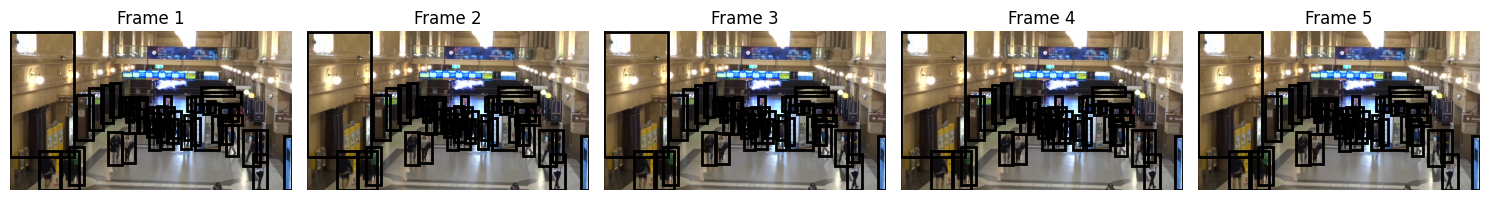

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Sequence name
seq = 'MOT20-01'

# Base path
base    = f'/content/MOT20/train/{seq}/'
img_dir = base + 'img1/'
gt_file = base + 'gt/gt.txt'

# Read the ground‑truth file
cols = ['frame','id','bb_left','bb_top','bb_w','bb_h','conf','x','y','z']
gt   = pd.read_csv(gt_file, header=None, names=cols)

# Pick the first 5 unique frames
frames = sorted(gt.frame.unique())[:5]

# Plot each frame with its bboxes
fig, axs = plt.subplots(1, len(frames), figsize=(15,5))
for ax, f in zip(axs, frames):
    img = Image.open(f"{img_dir}{f:06d}.jpg")
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Frame {f}")
    for _, row in gt[gt.frame==f].iterrows():
        ax.add_patch(plt.Rectangle(
            (row.bb_left, row.bb_top),
            row.bb_w, row.bb_h,
            fill=False, linewidth=2
        ))
plt.tight_layout()
plt.show()

**Note:**
The overlaid bounding boxes show ground-truth tracks of individuals across frames, illustrating core tracking challenges like occlusions, crowding, and scale variation.
